<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_tf = 1/33  # Tensor–Flavor coupling strength


In [ ]:
def generate_tensor_field(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X) * np.sin(Y)


In [ ]:
def generate_flavor_triplet(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    electron = np.sin(X)
    muon     = np.sin(Y + np.pi/3)
    tau      = np.sin(X + Y + 2*np.pi/3)
    return electron, muon, tau


In [ ]:
def tensor_flavor_coupling(tensor, electron, muon, tau, beta=1/33):
    grad_T_x, grad_T_y = np.gradient(tensor)
    grad_E_x, grad_E_y = np.gradient(electron)
    grad_M_x, grad_M_y = np.gradient(muon)
    grad_TAU_x, grad_TAU_y = np.gradient(tau)

    theta_T = np.arctan2(grad_T_y, grad_T_x)
    theta_E = np.arctan2(grad_E_y, grad_E_x)
    theta_M = np.arctan2(grad_M_y, grad_M_x)
    theta_TAU = np.arctan2(grad_TAU_y, grad_TAU_x)

    # Coupling terms
    coupling_E = -beta * np.sin(theta_T - theta_E)
    coupling_M = -beta * np.sin(theta_T - theta_M)
    coupling_TAU = -beta * np.sin(theta_T - theta_TAU)

    electron += coupling_E
    muon     += coupling_M
    tau      += coupling_TAU

    return tensor, electron, muon, tau


In [ ]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [ ]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


Tensor fidelity:   0.9415
Electron fidelity: 0.9694
Muon fidelity:     0.9696
Tau fidelity:      0.9695


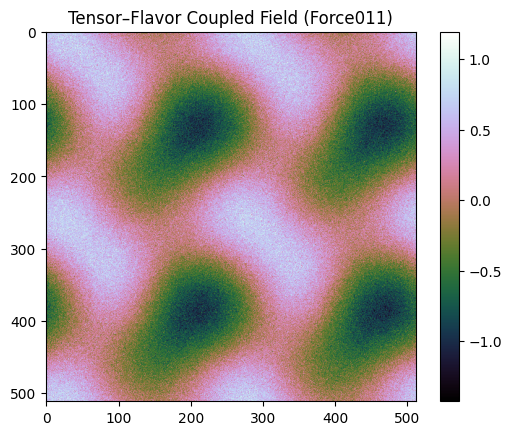

In [ ]:
tensor = generate_tensor_field(grid_size)
electron, muon, tau = generate_flavor_triplet(grid_size)
tensor_c, electron_c, muon_c, tau_c = tensor_flavor_coupling(tensor, electron, muon, tau, beta_tf)

tensor_e = evolve_field(tensor_c, e_folds)
electron_e = evolve_field(electron_c, e_folds)
muon_e     = evolve_field(muon_c, e_folds)
tau_e      = evolve_field(tau_c, e_folds)

f_T = memory_fidelity(tensor_c, tensor_e)
f_E = memory_fidelity(electron_c, electron_e)
f_M = memory_fidelity(muon_c, muon_e)
f_TAU = memory_fidelity(tau_c, tau_e)

print(f"Tensor fidelity:   {f_T:.4f}")
print(f"Electron fidelity: {f_E:.4f}")
print(f"Muon fidelity:     {f_M:.4f}")
print(f"Tau fidelity:      {f_TAU:.4f}")

plt.imshow(tensor_e + electron_e + muon_e + tau_e, cmap='cubehelix')
plt.title("Tensor–Flavor Coupled Field (Force011)")
plt.colorbar()
plt.show()
